# Evidence Synthesis — Hotel Towel Reuse

This notebook uses a **Bayesian hierarchical binomial model** to synthesise the seven randomised hotel towel-reuse studies.

We will:

1. Model the response with a binomial likelihood.
2. Account for between-study heterogeneity with a study-level random intercept.
3. Estimate parameters using Bayesian inference.
4. Report posterior means and 90% probability intervals.
5. Test whether the social-norm intervention has an effect.

The main model is

$$
Y_{ij} \sim \mathrm{Binomial}(n_{ij}, p_{ij})
$$

$$
\mathrm{logit}(p_{ij}) = \alpha_j + \beta x_{ij}
$$

with

$$
\alpha_j \sim N(\mu_\alpha, \sigma_\alpha)
$$

Here, $x_{ij}=0$ denotes the control group and $x_{ij}=1$ denotes the social-norm intervention group.

The parameter $\beta$ represents the intervention effect, while $\sigma_\alpha$ describes the between-study heterogeneity.

## 1. Imports

If necessary, install the packages first with `%pip install pandas numpy matplotlib bambi arviz`.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bambi as bmb
import arviz as az

## 2. Load the data


In [5]:

data_file = "towelData.csv"
data = pd.read_csv(data_file, sep=";", encoding="latin1")

display(data)
print(data.dtypes)


,Source,AuthorName,Experiment,Year,Group,Towel.Reuse,Count
0,Goldstein.2008.Ex1,Goldstein et al.,1,2008,Control,Yes,74
1,Goldstein.2008.Ex1,Goldstein et al.,1,2008,Social Norm,Yes,98
2,Goldstein.2008.Ex1,Goldstein et al.,1,2008,Control,No,137
3,Goldstein.2008.Ex1,Goldstein et al.,1,2008,Social Norm,No,124
4,Goldstein.2008.Ex2,Goldstein et al.,2,2008,Control,Yes,103
5,Goldstein.2008.Ex2,Goldstein et al.,2,2008,Social Norm,Yes,587
6,Goldstein.2008.Ex2,Goldstein et al.,2,2008,Control,No,174
7,Goldstein.2008.Ex2,Goldstein et al.,2,2008,Social Norm,No,731
8,Schulz2008.Ex2,Schulz et al.,2,2008,Control,Yes,77
9,Schulz2008.Ex2,Schulz et al.,2,2008,Social Norm,Yes,406


Source           str
AuthorName       str
Experiment     int64
Year           int64
Group            str
Towel.Reuse      str
Count          int64
dtype: object


## 3. Convert the data to long format

The supplied data contain four rows per study in the order:

- control + yes
- social norm + yes
- control + no
- social norm + no

We create one row per study × group with `reuse`, `total`, `group`, and `study`.

In [6]:

count = data.iloc[:, -1]

control_yes = count[::4].to_numpy()
social_yes = count[1::4].to_numpy()
control_no = count[2::4].to_numpy()
social_no = count[3::4].to_numpy()

control_total = control_yes + control_no
social_total = social_yes + social_no
study = np.arange(1, len(control_yes) + 1)

control_data = pd.DataFrame({
    "reuse": control_yes,
    "total": control_total,
    "group": "control",
    "study": study
})

social_data = pd.DataFrame({
    "reuse": social_yes,
    "total": social_total,
    "group": "social",
    "study": study
})

combined_data = pd.concat([control_data, social_data], ignore_index=True)
combined_data["reuse"] = combined_data["reuse"].astype(int)
combined_data["total"] = combined_data["total"].astype(int)
combined_data["group"] = pd.Categorical(
    combined_data["group"], categories=["control", "social"]
)
combined_data["study"] = combined_data["study"].astype("category")

combined_data["reuse_rate"] = combined_data["reuse"] / combined_data["total"]

display(combined_data)


,reuse,total,group,study,reuse_rate
0,74,211,control,1,0.350711
1,103,277,control,2,0.371841
2,77,135,control,3,0.570370
3,82,187,control,4,0.438503
4,21,25,control,5,0.840000
5,123,147,control,6,0.836735
6,28,30,control,7,0.933333
7,98,222,social,1,0.441441
8,587,1318,social,2,0.445372
9,406,655,social,3,0.619847


In [7]:

print("Number of studies:", combined_data["study"].nunique())
print("\nTotal observations:", len(combined_data))
print("\nMissing values:")
print(combined_data.isna().sum())


Number of studies: 7

Total observations: 14

Missing values:
reuse         0
total         0
group         0
study         0
reuse_rate    0
dtype: int64


## 4. Visualise observed reuse proportions

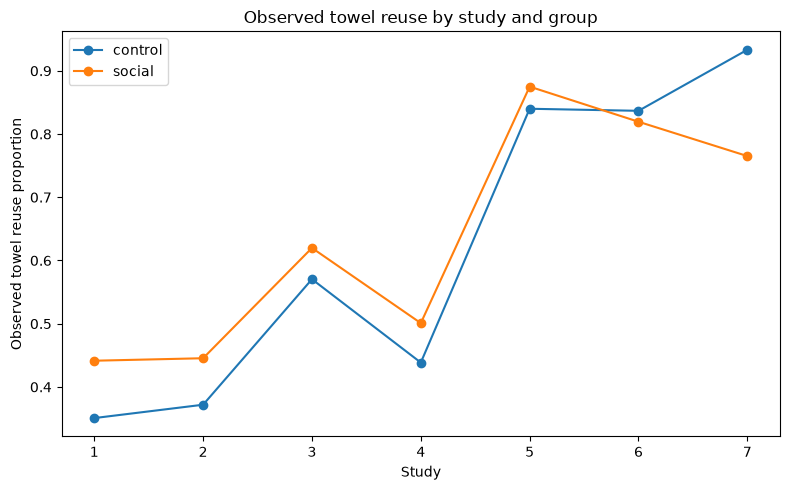

In [8]:

fig, ax = plt.subplots(figsize=(8, 5))

for group in ["control", "social"]:
    s = combined_data[combined_data["group"] == group]
    ax.plot(
        s["study"].astype(str), s["reuse_rate"],
        marker="o", label=group
    )

ax.set_xlabel("Study")
ax.set_ylabel("Observed towel reuse proportion")
ax.set_title("Observed towel reuse by study and group")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Bayesian hierarchical model

The response is a count of successes out of a known number of trials, so a **binomial distribution** is appropriate:

$$
Y_{ij} \sim \mathrm{Binomial}(n_{ij}, p_{ij})
$$

We use a logit link:

$$
\mathrm{logit}(p_{ij}) = \alpha_j + \beta x_{ij}
$$

The study-specific intercepts are hierarchical:

$$
\alpha_j \sim N(\mu_\alpha, \sigma_\alpha)
$$

This is a random-intercept model. It allows the baseline towel-reuse rate to differ between studies while partially pooling the study estimates.

In Bambi, `(1 | study)` specifies this random intercept.

In [10]:
# Corrected model specification for binomial family
model = bmb.Model(
    "reuse ~ group + (1 | study)",  # Removed trials() from response, moved to family
    combined_data,
    family="binomial",
    # Specify the number of trials in the family parameter
    # Assuming 'total' is your trials column
    priors={"trials": "total"}  # or use the appropriate parameter for your bmb version
)

# Alternative approach if the above doesn't work:
# Create a success/failure format
# combined_data['failures'] = combined_data['total'] - combined_data['reuse']
# model = bmb.Model(
#     "(reuse, failures) ~ group + (1 | study)",
#     combined_data,
#     family="binomial"
# )

model

C:\Users\Elena\anaconda3\Lib\site-packages\bambi\models.py:528: UserWarning: Unused name(s) in `priors`: ['trials']. They will be ignored. Set `bmb.config["UNUSED_PRIORS"]` to change this.
  warnings.warn(message + " They will be ignored." + hint, UserWarning)


       Formula: reuse ~ group + (1 | study)
        Family: binomial
          Link: p = logit
  Observations: 14
        Priors: 
    target = p
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 1.5)
            group ~ Normal(mu: 0.0, sigma: 1.0)
        
        Group-level effects
            1|study ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 2.5495))

### Prior predictive / prior inspection

In [21]:
model = bmb.Model(
    "p(reuse, total) ~ group + (1 | study)",
    combined_data,
    family="binomial"
)

In [22]:
model

       Formula: p(reuse, total) ~ group + (1 | study)
        Family: binomial
          Link: p = logit
  Observations: 14
        Priors: 
    target = p
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 1.5)
            group ~ Normal(mu: 0.0, sigma: 1.0)
        
        Group-level effects
            1|study ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 2.5495))


For this assignment we can use Bambi's default weakly informative priors unless your course specifies different priors. The important point is that the model is explicitly Bayesian and hierarchical.

Sampling: [1|study_sigma, Intercept, group]


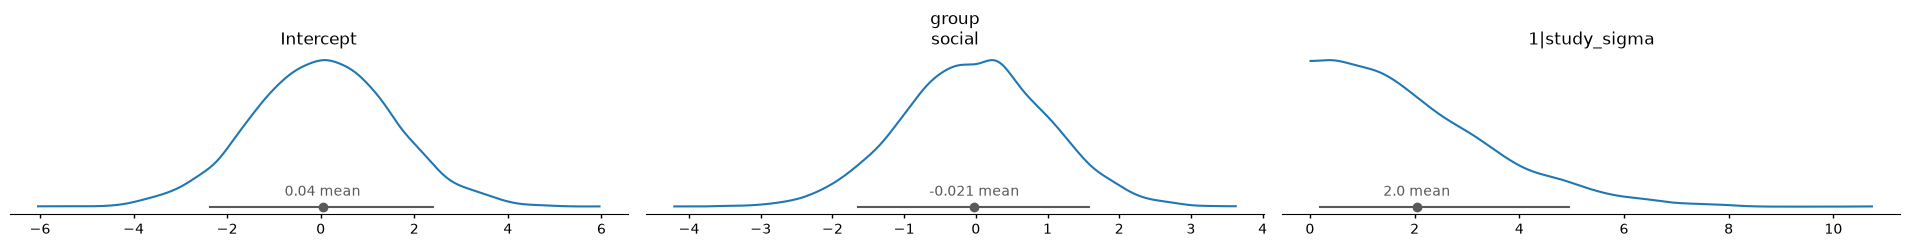

In [24]:
# Build the model first before plotting priors
model.build()  # This builds the model structure

# Now you can plot the priors
model.plot_priors()
plt.tight_layout()
plt.show()

## 6. Fit the model

In [26]:

results = model.fit(
    draws=2000,
    tune=2000,
    chains=4,
    cores=1, #only 1 CPU in localhost #够用但是慢一点
    random_seed=123
)


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [Intercept, group, 1|study_sigma, 1|study_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 126 seconds.
There were 37 divergences after tuning. Increase `target_accept` or reparameterize.


## 7. Check convergence

In [29]:
# Posterior summary

az.summary(results, ci_prob=0.90)

,mean,sd,eti90_lb,eti90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,0.42,0.41,-0.25,1.1,1172,1051,1.01,0.012,0.0084
group[social],0.207,0.075,0.082,0.33,4984,4201,1.00,0.0011,0.00096
1|study_sigma,1.1,0.37,0.64,1.8,1106,1021,1.01,0.013,0.017
1|study[1],-0.94,0.41,-1.6,-0.25,1172,1110,1.01,0.012,0.0082
1|study[2],-0.86,0.4,-1.5,-0.19,1174,1060,1.01,0.012,0.0082
1|study[3],-0.14,0.4,-0.8,0.54,1193,1036,1.00,0.012,0.0081
1|study[4],-0.63,0.41,-1.3,0.045,1177,1029,1.00,0.012,0.0083
1|study[5],1.13,0.52,0.31,2,1958,2565,1.00,0.012,0.0084
1|study[6],0.94,0.41,0.28,1.6,1195,1127,1.00,0.012,0.008
1|study[7],0.76,0.43,0.061,1.5,1489,1902,1.00,0.011,0.0073


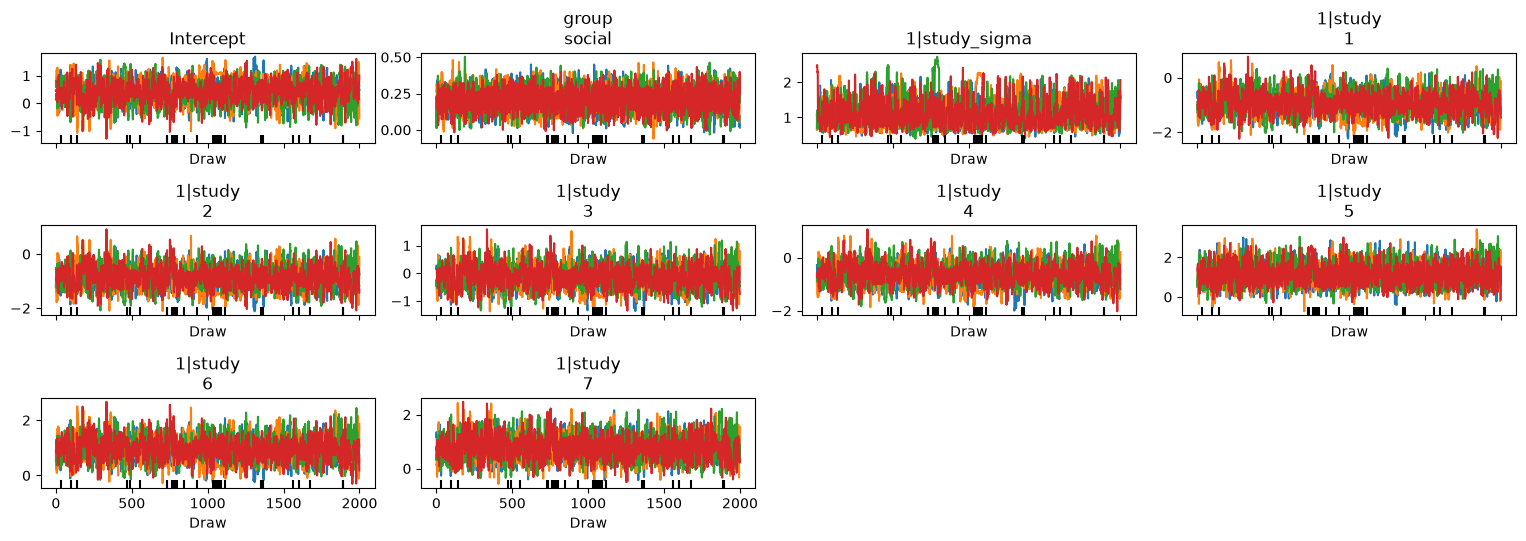

In [30]:

az.plot_trace(results)
plt.tight_layout()
plt.show()


## 8. Identify the intervention parameter

The intervention parameter is the coefficient for `group[social]`.

The posterior estimate is:

$$
\beta = 0.207
$$

with a 90% probability interval of

$$
[0.082,\ 0.330].
$$

The corresponding odds ratio is

$$
OR=e^{0.207}\approx1.23.
$$

Thus, the posterior mean corresponds to an odds of towel reuse that is approximately 1.23 times as high in the social-norm intervention group as in the control group.



In [34]:

print("Posterior variables:")
for name in results.posterior.data_vars:
    print(" -", name)


Posterior variables:
 - Intercept
 - group
 - 1|study_sigma
 - 1|study


## 9. Posterior summary and 90% probability interval

The assignment asks for posterior means and 90% probability intervals.

In [35]:

beta_mean = beta.mean()
beta_lower, beta_upper = np.quantile(beta, [0.05, 0.95])

print(f"Intervention effect beta (posterior mean): {beta_mean:.3f}")
print(f"90% probability interval: [{beta_lower:.3f}, {beta_upper:.3f}]")


NameError: name 'beta' is not defined

### Odds ratio

Because the model uses a logit link,

\[
OR=e^\beta.
\]

An odds ratio of 1 corresponds to no intervention effect.

In [ ]:

or_draws = np.exp(beta)
or_mean = or_draws.mean()
or_lower, or_upper = np.quantile(or_draws, [0.05, 0.95])

print(f"Odds ratio (posterior mean): {or_mean:.3f}")
print(f"90% probability interval: [{or_lower:.3f}, {or_upper:.3f}]")


## 10. Bayesian hypothesis test

We formulate

\[
H_0:\beta=0
\]

versus

\[
H_1:\beta\neq0.
\]

Rather than using a frequentist p-value, we examine the posterior distribution. A particularly direct quantity is

\[
P(\beta>0\mid\text{data}).
\]

If the 90% probability interval excludes zero, the posterior places most of its mass on one side of zero. If zero lies inside the interval, the posterior uncertainty still includes no effect.

In [36]:

prob_positive = np.mean(beta > 0)
prob_negative = np.mean(beta < 0)

print(f"P(beta > 0 | data) = {prob_positive:.3f}")
print(f"P(beta < 0 | data) = {prob_negative:.3f}")
print(f"90% PI for beta = [{beta_lower:.3f}, {beta_upper:.3f}]")


NameError: name 'beta' is not defined

In [ ]:

az.plot_posterior(
    results,
    var_names=[effect_name],
    hdi_prob=0.90,
    ref_val=0
)
plt.tight_layout()
plt.show()


## 11. Between-study heterogeneity

The random-intercept standard deviation \(\sigma_\alpha\) describes variation in baseline log-odds between studies. Inspect the posterior parameters containing `study_sigma` or `study` in their name.

In [ ]:

for name in results.posterior.data_vars:
    print(name)


In [ ]:

# Bambi commonly names the random-effect SD something like "1|study_sigma".
# The following finds likely study-level SD parameters automatically.
heterogeneity_names = [
    name for name in results.posterior.data_vars
    if "study" in name.lower() and "sigma" in name.lower()
]

if heterogeneity_names:
    display(
        az.summary(
            results,
            var_names=heterogeneity_names,
            hdi_prob=0.90,
            round_to=3
        )[["mean", "sd", "hdi_5%", "hdi_95%", "r_hat"]]
    )
else:
    print("No study-level sigma parameter was found automatically; inspect the names above.")


## 12. Final results table

This compact table gives the main quantities needed for the assignment.

In [ ]:

final_results = pd.DataFrame({
    "parameter": ["beta", "odds_ratio", "P(beta > 0)"],
    "posterior_mean": [beta_mean, or_mean, prob_positive],
    "lower_90%": [beta_lower, or_lower, np.nan],
    "upper_90%": [beta_upper, or_upper, np.nan]
})

display(final_results.round(3))


## 13. Interpretation template

After running the notebook, replace the brackets with your actual numerical results:

> We modelled towel reuse as a binomial response, with the number of guests in each group as the number of trials. The logit reuse probability was modelled as a function of intervention group, with a study-level random intercept to account for between-study heterogeneity.
>
> The posterior mean of the intervention coefficient \(\beta\) was **[value]**, with a 90% probability interval of **[lower, upper]**. The corresponding posterior mean odds ratio was **[value]**, with a 90% probability interval of **[lower, upper]**.
>
> We considered \(H_0:\beta=0\) versus \(H_1:\beta\neq0\). The posterior probability of a positive intervention effect was \(P(\beta>0\mid data)=\) **[value]**. The 90% probability interval **[did/did not]** include zero. Therefore, the posterior provides **[describe the evidence and direction without using a frequentist p-value]** regarding the effectiveness of the social-norm intervention.
>
> The posterior distribution of the study-level standard deviation \(\sigma_\alpha\) was **[value]**, with a 90% probability interval of **[lower, upper]**, indicating **[describe between-study heterogeneity]**.